# 🛰️ Trabajo Práctico — Métodos Numéricos

El siguiente archivo contendrá en formato de celdas los diversos problemas. Resuelva el trabajo práctico utilizando celdas de código para la resolución de problemas (si cree importante puede remarcar con comentarios). Utilice markdown para responder a las preguntas conceptuales. Las consignas pueden en ciertos casos ser abiertas a interpretación, está más que invitado a explorar y variar para estudiar las consignas a gusto.
## Reconstrucción de la trayectoria e imagen de un dron

---

Un dron de monitoreo perdió su sistema GPS durante una misión. Se dispone de:

- mediciones de distancia desde estaciones terrestres,
- posiciones con ruido en tiempos discretos,
- una imagen de baja resolución (8×8).

El objetivo es reconstruir su trayectoria y mejorar la información disponible utilizando herramientas numéricas.

---

## 🔹 Parte 1 — Trilateración y métodos de Newton

Se conocen tres estaciones en posiciones:
$$
(x_1,y_1),\ (x_2,y_2),\ (x_3,y_3)
$$

y distancias medidas a puntos (x,y) respecto de los sensores en las estaciones: $d_1,\ d_2,\ d_3$. (Los datos se encuentran en mediciones_trayectoria.csv) y la posición x e y de los sensores se encuentran en sensores.csv). (Si le interesa puede investigar que para un problema de geolocalización uno representa en longitud latitud en algún sistema, y luego para medir distancias se debe proyectar a algun sistema métrico, no es relevante para la resolución de este TP.)

## Consignas

1.  Para resolver las ubicaciones x,y de los puntos se utiliza la distancia a los sensores. Plantear el sistema no lineal:
$$
F(x,y)=
\begin{cases}
(x-x_1)^2+(y-y_1)^2-d_1^2 \\
(x-x_2)^2+(y-y_2)^2-d_2^2 \\
(x-x_3)^2+(y-y_3)^2-d_3^2
\end{cases}
$$

2. Resolver el problema utilizando el método de Newton. Considere el caso de Newton de 2 variables y piense una estrategia para poder obtener la solución al problema. Intente hacer un esquema conceptual de por qué se necesitan las 3 ecuaciones.


3. Analizar la convergencia estudiando el número de iteraciones y la dependencia de la condición inicial. Estudie el orden de convergencia del método.

## Preguntas adicionales

- ¿Qué ocurre si el punto inicial está lejos?
- ¿El sistema siempre tiene solución exacta?
- ¿Cómo influye el ruido en las distancias?
- ¿Qué método se le ocurre para seleccionar la semilla?

In [ ]:
import numpy as np

def F(x, y, d1, d2): # f1 y f2
    return np.array([
        (x - x1)**2 + (y - y1)**2 - d1**2,
        (x - x2)**2 + (y - y2)**2 - d2**2
    ])

def F3(x, y, d3):
    return (x - x3)**2 + (y - y3)**2 - d3**2

def J(x, y): # jacobiano de F (f1 y f2)
    return np.array([
        [2 * (x - x1), 2 * (y - y1)],
        [2 * (x - x2), 2 * (y - y2)]
    ])

def generar_semillas(d1, d2, d3, x_ant, y_ant):
    semillas = []
    semillas.append((x_ant, y_ant, "Punto anterior")) # pruebo desde el punto anterior

    # veo cual sensor esta mas cerca
    if d1 <= d2 and d1 <= d3:
        xCercano, yCercano = x1, y1
        r = d1

    elif d2 <= d1 and d2 <= d3:
        xCercano, yCercano = x2, y2
        r = d2

    else:
        xCercano, yCercano = x3, y3
        r = d3

    for i in range(15):# agarro puntos sobre ese circulo
        ang = 2 * np.pi * i / 15 # divido a 2pi en 15 partes
        x0 = xCercano + r * np.cos(ang)
        y0 = yCercano + r * np.sin(ang)
        semillas.append((x0, y0, "Punto en circulo mas cercano"))

    # algunos random cerca del anterior por si acaso
    for _ in range(5):
        x0 = x_ant + np.random.uniform(-1, 1)
        y0 = y_ant + np.random.uniform(-1, 1)
        semillas.append((x0, y0, "Punto random"))

    return semillas

def definir_x_e_y(d1, d2, d3, x0, y0, max_iter=100):
    p = np.array([x0, y0], dtype=float)

    for i in range(max_iter):
        x, y = p[0], p[1]
        f = F(x, y, d1, d2)
        jacobiano = J(x, y)
        jacobiano_inv = np.linalg.inv(jacobiano)
        p = p - jacobiano_inv @ f
        v = F(p[0], p[1], d1, d2)

        if np.linalg.norm(v) < 1e-6 and np.abs(F3(p[0], p[1], d3)) < 1e-6:
            return p, i

    return None

sensores = {}

with open ("sensores.csv", "r") as archivo:
    archivo.readline()
    contenido = archivo.readlines()

    for linea in contenido:
        linea = linea.strip().split(",")
        sensores[linea[0]] = (float(linea[1]), float(linea[2]))

mediciones = []

with open("mediciones_trayectoria.csv", "r") as archivo:
    archivo.readline()

    for linea in archivo:
        linea = linea.strip().split(",")
        t = int(linea[0])
        d1 = float(linea[1])
        d2 = float(linea[2])
        d3 = float(linea[3])
        mediciones.append((t, d1, d2, d3))

x1, y1 = sensores["Sensor 1"]
x2, y2 = sensores["Sensor 2"]
x3, y3 = sensores["Sensor 3"]

trayectoria = []
x, y = 0.0, 0.0

for t, d1, d2, d3 in mediciones:
    semillas = generar_semillas(d1, d2, d3, x, y)
    solucion = None
    semilla = ""

    for x0, y0, descripcion in semillas:
        res = definir_x_e_y(d1, d2, d3, x0, y0)

        if res is not None:
            solucion, iteraciones = res
            semilla = descripcion
            break

    if solucion is None:
        raise ValueError("No converge con ninguna semilla")

    x, y = solucion
    trayectoria.append((t, x, y, semilla, iteraciones))

for punto in trayectoria:
    print(f"t = {punto[0]}, x = {punto[1]:.4f}, y = {punto[2]:.4f}, semilla = {punto[3]}, iteraciones = {punto[4]}")

t = 0, x = 1.0000, y = 0.0000, semilla = Punto anterior, iteraciones = 3
t = 1, x = 2.5403, y = 4.2074, semilla = Punto anterior, iteraciones = 5
t = 2, x = 7.5839, y = 4.5465, semilla = Punto anterior, iteraciones = 4
t = 3, x = 17.0100, y = 0.7056, semilla = Punto anterior, iteraciones = 6
t = 4, x = 31.3464, y = -3.7840, semilla = Punto en circulo mas cercano, iteraciones = 6
t = 5, x = 50.2837, y = -4.7946, semilla = Punto anterior, iteraciones = 7
t = 6, x = 72.9602, y = -1.3971, semilla = Punto anterior, iteraciones = 8
t = 7, x = 98.7539, y = 3.2849, semilla = Punto en circulo mas cercano, iteraciones = 7
t = 8, x = 127.8545, y = 4.9468, semilla = Punto anterior, iteraciones = 13
t = 9, x = 161.0889, y = 2.0606, semilla = Punto en circulo mas cercano, iteraciones = 12
t = 10, x = 199.1609, y = -2.7201, semilla = Punto anterior, iteraciones = 9


# TP1 - Métodos Numéricos  
## Parte 1 - Trilateración y método de Newton

---

## 1. Problema

El objetivo es determinar la posición \(x, y\) del dron a partir de las distancias de tres sensores.

Cada distancia es una circunferencia centrada en el sensor correspondiente, por lo que el problema se puede modelar como la intersección de tres circunferencias.

Tengo un sistema de tres ecuaciones no lineales con dos incógnitas:

- Cada ecuación representa una circunferencia  
- La solución buscada es el punto donde las tres coinciden  

---

## 2. Resolución con el método de Newton

Para resolver el sistema se utilizó el método de Newton-Raphson en dos variables.

El método es iterativo y, a partir de una semilla, va generando sucesivas aproximaciones utilizando el Jacobiano del sistema.

Como Newton requiere un sistema cuadrado, se utilizaron dos ecuaciones para realizar las iteraciones.

---

## 3. Tercera ecuación

Aunque se itera con dos ecuaciones, la tercera ecuación es fundamental.

Geométricamente:
- dos circunferencias pueden intersectarse en dos puntos como maximo
- esto genera múltiples soluciones posibles  

La tercera ecuación permite verificar cuál de esas soluciones es válida, ya que solo una será consistente con la tercera distancia.

Por lo tanto:
- dos ecuaciones permiten encontrar valores posibles  
- la tercera permite validarlos  

---

## 4. Estrategia de selección de semillas

El método de Newton depende fuertemente de la condición inicial, por lo que se implementó una estrategia de múltiples semillas para mejorar la robustez.

En cada instante se probaron distintas semillas:

- el punto anterior de la trayectoria (por continuidad)
- puntos sobre la circunferencia del sensor más cercano
- puntos aleatorios cercanos (al final no fue necesario)

Se elige la primera semilla que logra converger correctamente.

Esta estrategia evita que el método falle cuando una única semilla no es adecuada.

---

## 5. Análisis de la convergencia

### Dependencia de la condición inicial

Se observó que la convergencia depende fuertemente de la semilla inicial.

En muchos casos, el método converge utilizando el punto anterior, lo cual es esperable porque la trayectoria es continua.

Sin embargo, en algunos instantes fue necesario utilizar otras semillas, lo que muestra que la elección inicial influye directamente en el resultado.

---

### Número de iteraciones

El número de iteraciones depende de la calidad de la semilla.

En las pruebas realizadas, el método convergió entre 3 y 13 iteraciones.

Cuando la semilla es buena (por ejemplo, el punto anterior), la convergencia es rápida.  
Cuando no lo es, el método puede necesitar más iteraciones.

---

### Orden de convergencia

El método de Newton tiene convergencia cuadrática cerca de la solución, lo que significa que el error disminuye rápidamente en cada iteración.

Esto se observa cuando la semilla inicial está cerca de la solución.  
Si no, la convergencia puede ser más lenta o incluso no darse.

---

## 6. Resultados observados

A partir de la ejecución del programa se observó que:

- en la mayoría de los casos, la solución se obtiene usando el punto anterior  
- en algunos instantes fue necesario usar semillas sobre la circunferencia  
- esto muestra que la continuidad de la trayectoria ayuda, pero no siempre es suficiente  

También se verificó que mejores semillas implican menor cantidad de iteraciones.

---

## 7. Preguntas adicionales

### ¿Qué ocurre si el punto inicial está lejos?

Si la semilla inicial está lejos de la solución, el método de Newton puede no converger o hacerlo hacia una solución incorrecta.

Esto sucede porque depende fuertemente de la semilla inicial.

---

### ¿El sistema siempre tiene solución exacta?

No necesariamente.

En el caso ideal, las tres circunferencias se intersecan en un único punto.  
Sin embargo, si hay errores en las mediciones, puede no existir una solución exacta que satisfaga las tres ecuaciones simultáneamente.

---

### ¿Cómo influye el ruido en las distancias?

El ruido genera inconsistencias entre las ecuaciones.

Esto puede causar:
- falta de solución exacta  
- mayor número de iteraciones  
- dependencia aún mayor de la semilla  

En general, a mayor ruido, menor precisión en la solución.

---

### ¿Qué método se puede usar para seleccionar la semilla?

Una buena estrategia es aprovechar la información del problema:

- usar el punto anterior (continuidad)
- usar el sensor más cercano y generar puntos sobre su circunferencia
- agregar semillas alternativas como respaldo  

Esto permite mejorar significativamente la convergencia sin modificar el método de Newton.

---

## 8. Conclusión

El método de Newton es adecuado para resolver este problema, pero su principal limitación es la dependencia de la condición inicial.

Para resolver esto, se implementó una estrategia de múltiples semillas basada en la geometría del problema.

Esto permitió mejorar la robustez del método y asegurar la convergencia en todos los casos analizados.

# 🔹 Parte 2 — Precisión numérica y reescalado

En esta parte se analiza cómo la representación numérica afecta los resultados.

1. Resolver el problema de la Parte 1 utilizando:
   - precisión simple (`float32`)
   - doble precisión (`float64`)

2. Comparar los resultados obtenidos.

3. Repetir el cálculo luego de reescalar el problema y resolverlo. Luego volver a las unidades originales y comparar si de esta manera mejora el error.

Definir una escala característica \(L\) (por ejemplo \(L = 1000\)). El proposito de esto es que los valores utilizados se muevan del orden de 1 (si L es la distancia máxima por ejemplo, los valores se moveran entre 0 y 1) y trabajar con:

$$
x' = \frac{x}{L}, \quad y' = \frac{y}{L}
$$
$$
x_i' = \frac{x_i}{L}, \quad y_i' = \frac{y_i}{L}, \quad d_i' = \frac{d_i}{L}
$$


- Comparar:
  - solución original vs reescalada
  - errores en cada caso

- Evaluar:
  - número de iteraciones
  - estabilidad del método

## Preguntas
- ¿Por qué el reescalado puede mejorar los resultados?
- ¿Qué sucede con términos como \(x^2\) en distintas escalas?
- ¿Se observan efectos de cancelación numérica?

## 🔹 Parte 3 — Interpolación de la trayectoria

Utilizando una de las trayectorias obtenidas puede obtener valores intermedios de puntos. Usted cuenta con puntos (x(t),y(t)) (Tiene un ground truth de mediciones que es trayectoria_ground_truth.csv)

## Consignas

1. Obtenga una interpolación de la curva usando interpolación de Lagrange. Puede adicionalmente agregar puntos artificiales a la curva generando usted nuevas mediciones. Observa algun comportamiento particular al aumentar la cantidad de puntos? Mueste gráficos relevantes de la interpolación (en este caso puede utilizar una librería que le obtenga el polinomio de Lagrange).

2. Implementar un spline cúbico natural y compare al aumentar puntos que sucede(en este caso puede utilizar una librería que le calcule el spline).

3. Generar múltiples realizaciones con ruido: $y_i^{(k)} = y_i + \epsilon_k$ que simulan distantas instancias de lsa mismas mediciones. Extraiga ese ruido utilizando alguna distribución conocida. Para cada conjunto construir $S_k(t)$ . Calcular $\bar{S}(t) = \frac{1}{N} \sum S_k(t)$ y construir $S_{\text{prom}}(t)$. Comparar ambos resultados¿Se cumple que $\bar{S}(t) = S_{\text{prom}}(t)$?



## Preguntas

- ¿Qué efecto de error se induce al variar la cantidad de puntos en Lagrange?
- ¿Que beneficios ve al utilizar splines sobre lagrange?
- ¿Se le ocurre alguna mejora a alguno de los métodos?


# 🔹 Parte 4 — Reconstrucción de imagen (Interpolación bilineal)

Se dispone de una imagen en escala de grises de tamaño $8\times 8$ que fue extraída del drone (imagen_drone_8_8.png)



1. Construya una imagen de tamaño $(64\times 64)$ utilizando interpolación bilineal. Implemente el método usted y luego utilice alguna librería para poder comparar. Plotee ambas imagenes para ver como quedan. Vea al final para una ayuda de cómo pensarlo. Muestre un diagrama de cómo entiende el método en este caso.
2. Si tuviese el problema inverso, partiendo de una imagen de 64x64, ¿Se le ocurre algún método para reducir su tamaño perdiendo calidad?
3. Se tiene la imagen ground_truth la imagen ground_truth_100_100. Aplique la misma idea que 1 para llevarlo a 1000x1000.
- Ayuda: Para implementar 1 el método puede pensar a los puntos de la matriz grande como:
$x = \frac{i}{63} \cdot 7, \quad y = \frac{j}{63} \cdot 7$
- Comentario extra: No es necesario que use la imagen que le damos. Puede buscar la suya. Para imagenes satelitales si le interesa puede investigar con google earth engine




In [1]:
import math as m
import numpy as np

from PIL import Image

In [2]:
img = Image.open("imagen_drone_8_8.png").convert("L")  # "L" = grayscale
img_array = np.array(img)  # forma: (8, 8), values 0-255 (0=black, 255=white)

In [6]:
def bilineal(img_small, input_size, output_size):
    big_image = np.zeros((output_size, output_size))

    for i in range(output_size):
        for j in range(output_size):

            # coordenadas no enteras para intercalar en las de la imagen chica
            x = i/(output_size-1) * (input_size-1)
            y = j/(output_size-1) * (input_size-1)

            # encontrar los 4 pixels al rededor del i,j a agregar:

            x1 = min(m.floor(x), input_size-2)
            x2 = m.ceil(x)

            y1 = min(m.floor(y), input_size-2)
            y2 = m.ceil(y)

            """sobre el limite intferior:
                En x = i/63 *7, cuando llega a i =63 queda exactamente x =7.0
                O sea que floor(x) = 7, pero no existe el índice 8 en la foto 8×8 (el max es 7). No queda otra que doblar para adentro las esquinas para que no se vayan "out of bounds" — si floor_x es 7, min(floor_x, 6) da 6 y el último pixel entonces queda entre 6 y 7 y no se va volando """

            """si alguno de los bordes ya es un número entero, floor y ceil no hacen nada y dx o dy es cero. no pasa nada, es lo que tiene que pasar. Matemáticamente no se rompe nada :)"""

            # dx, dy la distancia entre x1,y1 y x,y

            dx = x - x1
            dy = y - y1

            # interpolación bilinear formula

            top = (1 - dx) * img_small[x1, y1] + dx * img_small[x2, y1]
            bot = (1 - dx) * img_small[x1, y2] + dx * img_small[x2, y2]

            res = (1 - dy) * top + dy * bot

            # TO-DO assign to big_image[i, j]

            big_image[i, j] = res

    return big_image.astype(np.uint8)

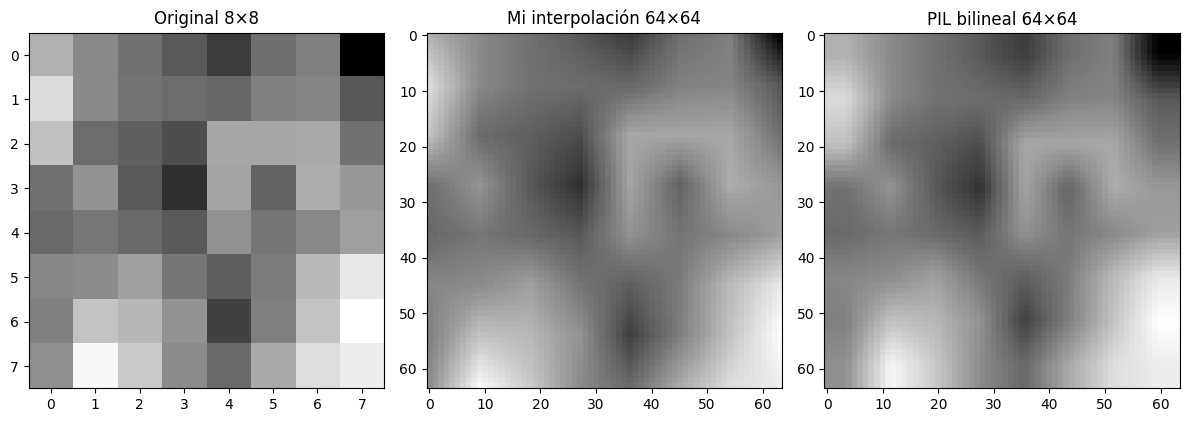

In [7]:
import matplotlib.pyplot as plt

# run your function
img_big = bilineal(img_array, 8, 64)

# compare with PIL's built-in bilinear (for reference)
img_pil = img.resize((64, 64), Image.BILINEAR)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original 8×8")

axes[1].imshow(img_big, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Mi interpolación 64×64")

axes[2].imshow(img_pil, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("PIL bilineal 64×64")

plt.tight_layout()
plt.show()